# Modeling: Predicting Conflicting ClinVar Classifications

### Objective
Train and evaluate a binary classifier that predicts whether a genetic variant's clinical interpretations are **Conflicting** (`class = 1`) or **Concordant** (`class = 0`), using the fully encoded, model-ready dataset produced during the cleaning stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import joblib

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/processed/clinvar_model_ready.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (65188, 57)


,pos,ref,alt,class,allele,consequence,impact,symbol,feature,amino_acids,codons,strand,loftool,cadd_phred,missense_variant,5_prime_utr_variant,intron_variant,3_prime_utr_variant,2kb_upstream_variant,synonymous_variant,500b_downstream_variant,splice_donor_variant,frameshift_variant,nonsense,splice_acceptor_variant,clinical_disease_count,mean_af,chrom_10,chrom_11,chrom_12,chrom_13,chrom_14,chrom_15,chrom_16,chrom_17,chrom_18,chrom_19,chrom_2,chrom_20,chrom_21,chrom_22,chrom_3,chrom_4,chrom_5,chrom_6,chrom_7,chrom_8,chrom_9,chrom_MT,chrom_X,clnvc_Duplication,clnvc_Indel,clnvc_Insertion,clnvc_Inversion,clnvc_Microsatellite,clnvc_single_nucleotide_variant,feature_type_Transcript
0,1168180,437,106,0,88,17,2,200,1700,257,1653,1.0,0.157,1.053,1,0,0,0,0,0,0,0,0,0,0,0,0.090419,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,1470752,437,0,0,1,17,2,2135,463,756,1143,-1.0,0.157,31.000,1,0,0,0,0,0,0,0,0,0,0,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,1737942,0,213,1,168,17,2,892,849,480,813,-1.0,0.157,28.100,1,1,0,0,0,0,0,0,0,0,0,6,0.000003,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,2160305,437,0,0,1,17,2,1889,1893,377,523,1.0,0.157,22.500,1,0,0,0,0,0,0,0,0,0,0,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
4,2160305,437,335,0,296,17,2,1889,1893,362,525,1.0,0.157,24.700,1,0,0,0,0,0,0,0,0,0,0,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


## Feature Selection

- **Dropping `pos`:** the raw genomic coordinate is almost a unique identifier (63,115 unique values across 65,188 rows). Like `CLNHGVS` in the cleaning stage, keeping it risks the model memorizing specific positions instead of learning generalizable patterns, without adding real predictive value.
- **Target:** `class` (0 = Concordant, 1 = Conflicting).
- All remaining columns are used as features — they are already fully numeric (one-hot, ordinal, and label encoded).

In [3]:
X = df.drop(columns=['class', 'pos'])
y = df['class']

print("Features:", X.shape[1])
print("Target distribution (%):\n", y.value_counts(normalize=True) * 100)

Features: 55
Target distribution (%):
 class
0    74.789839
1    25.210161
Name: proportion, dtype: float64


## Train/Test Split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain class ratio (%):\n", y_train.value_counts(normalize=True) * 100)
print("\nTest class ratio (%):\n", y_test.value_counts(normalize=True) * 100)

Train shape: (52150, 55) | Test shape: (13038, 55)

Train class ratio (%):
 class
0    74.790029
1    25.209971
Name: proportion, dtype: float64

Test class ratio (%):
 class
0    74.789078
1    25.210922
Name: proportion, dtype: float64


## Handling Class Imbalance


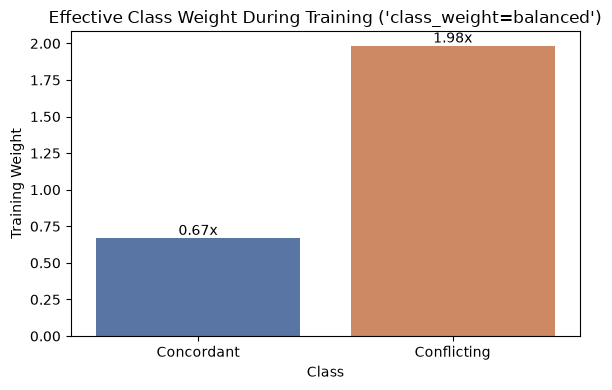

         Class  Training Weight
0   Concordant         0.668538
1  Conflicting         1.983342


In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_df = pd.DataFrame({'Class': ['Concordant', 'Conflicting'], 'Training Weight': weights})

plt.figure(figsize=(6, 4))
sns.barplot(data=weight_df, x='Class', y='Training Weight',
            hue='Class', palette={'Concordant': '#4C72B0', 'Conflicting': '#DD8452'}, legend=False)
plt.title("Effective Class Weight During Training ('class_weight=balanced')")
for i, v in enumerate(weight_df['Training Weight']):
    plt.text(i, v, f'{v:.2f}x', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(weight_df)

## Model 1: Logistic Regression (Baseline)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Logistic Regression is sensitive to feature scale (unlike Random Forest), and our
# label-encoded columns range from 0 to the thousands, so we scale features first.
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Concordant', 'Conflicting']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

  Concordant       0.84      0.46      0.60      9751
 Conflicting       0.32      0.75      0.45      3287

    accuracy                           0.53     13038
   macro avg       0.58      0.60      0.52     13038
weighted avg       0.71      0.53      0.56     13038

ROC-AUC: 0.663874309678191


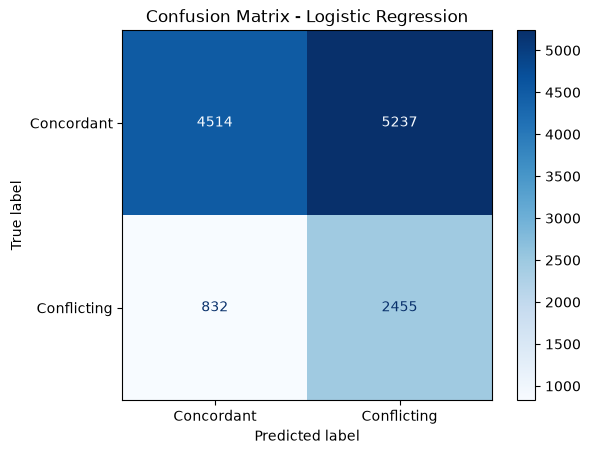

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Concordant', 'Conflicting'], cmap='Blues'
)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## Model 2: Random Forest

In [8]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Concordant', 'Conflicting']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

  Concordant       0.89      0.67      0.77      9751
 Conflicting       0.44      0.75      0.55      3287

    accuracy                           0.69     13038
   macro avg       0.66      0.71      0.66     13038
weighted avg       0.78      0.69      0.71     13038

ROC-AUC: 0.7903108827511143


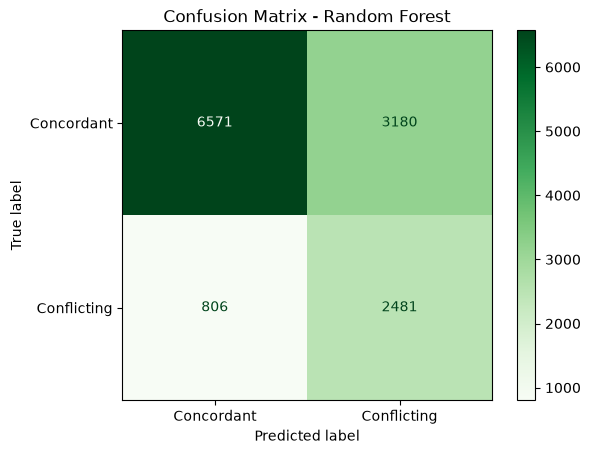

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Concordant', 'Conflicting'], cmap='Greens'
)
plt.title('Confusion Matrix - Random Forest')
plt.show()

## ROC Curve Comparison

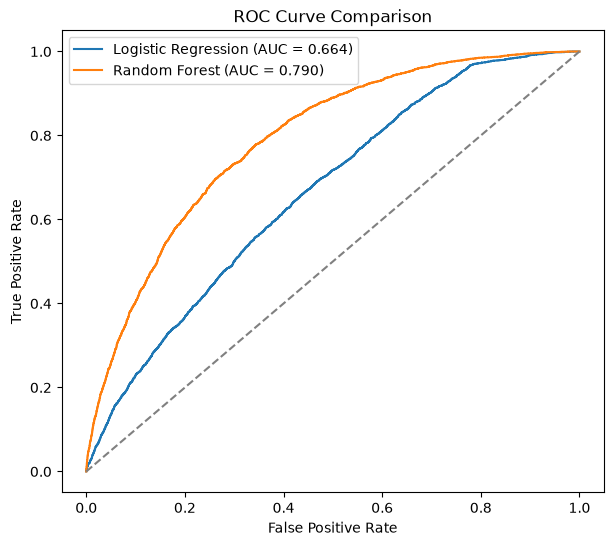

In [10]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Feature Importance (Random Forest)

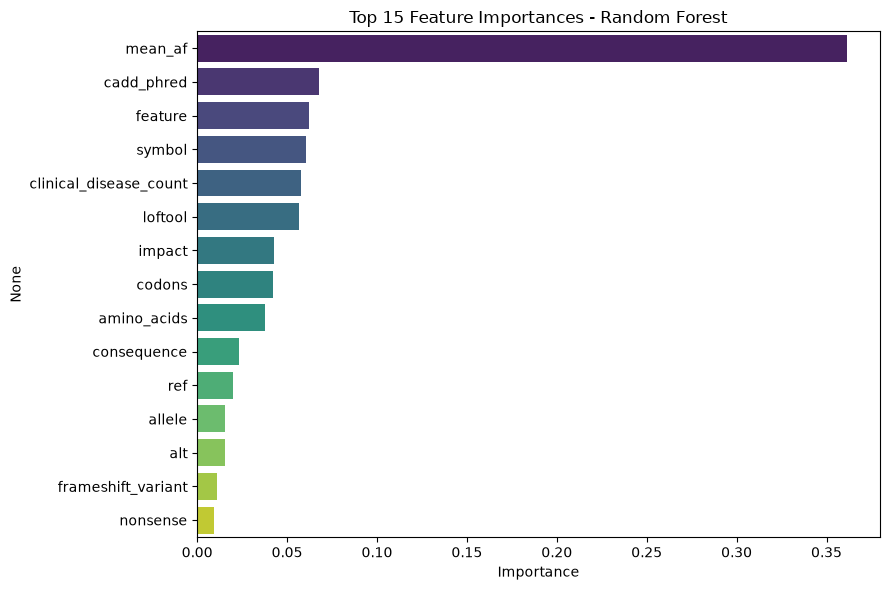

In [11]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Model Comparison Summary

In [12]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_reg.score(X_test, y_test), rf_clf.score(X_test, y_test)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)],
})
comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.534514,0.663874
1,Random Forest,0.694278,0.790311


## Saving the Final Model

We save the Random Forest model (best ROC-AUC) along with the feature column order, so the same model can be loaded and reused in the Streamlit dashboard.

In [13]:
joblib.dump(rf_clf, '/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/processed/rf_model.pkl')
joblib.dump(list(X.columns), '/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/processed/model_features.pkl')
print("Model and feature list saved.")

Model and feature list saved.


## Key Modeling Insights

1. **Class imbalance handling:** `class_weight='balanced'` gives the minority (Conflicting) class a training weight of ~1.98x versus ~0.67x for the majority class — this is what lets Random Forest reach 75% recall on Conflicting variants despite them being only a quarter of the data.
2. **Model comparison:** Random Forest (ROC-AUC 0.79) clearly beats Logistic Regression (ROC-AUC 0.66, even after scaling), confirming the EDA finding that the relationship between features and `class` is non-linear.
3. **Top predictive features:** `mean_af` (log-transformed mean allele frequency) dominates feature importance by a wide margin, followed by `cadd_phred`, `feature` (transcript), `symbol` (gene), `clinical_disease_count`, and `loftool` — variants that are rarer in the population and score higher on pathogenicity metrics are more likely to have conflicting interpretations.
4. **Trade-off:** the Random Forest favors recall over precision on the Conflicting class (0.75 vs 0.44) — it flags more true conflicting variants at the cost of some false positives, which is the safer trade-off for a clinical screening use case.
5. **Practical use:** the saved model (`rf_model.pkl`) can be loaded directly into the Streamlit dashboard to give users a live prediction for a chosen variant's feature values.